## Fit Rate Laktat

In [ ]:
# --- Fit-Rate (CRLB) Utilities ----------------------------------------------# --- Fit-Rate (CRLB) Utilities ----------------------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Fit-Rate (CRLB) Utilities ----------------------------------------------
import os
import numpy as np


def _suffix(quality_clip: bool, outlier_clip: bool) -> str:
    return "OutlierClip" if outlier_clip else ("QualityClip" if quality_clip else "Orig")


def load_sd_map(
    metabolite: str,
    method: str,
    *,
    data_dir: str = "MetabMaps",
    quality_clip: bool = False,
    outlier_clip: bool = False,
) -> np.ndarray:
    """
    Load LCModel SD/CRLB map (X,Y,Z,T) for a metabolite/method pair.
    """
    suffix = _suffix(quality_clip, outlier_clip)
    f_sd = os.path.join(
        data_dir, method, f"{metabolite}_sd_{method}_{suffix}.npy"
    )
    if not os.path.isfile(f_sd):
        raise FileNotFoundError(f"SD map missing: {f_sd}")

    sd = np.load(f_sd)
    if sd.ndim != 4:
        raise ValueError(f"Unexpected SD shape {sd.shape}, expected (X,Y,Z,T).")
    return sd


def load_brain_mask(
    subject: str,
    *,
    tissue_dir: str = "../datasets",
) -> np.ndarray:
    """
    Load brain mask (X,Y,Z). Axis order consistent with metabolite maps.
    """
    mask_path = os.path.join(tissue_dir, subject, "mask.npy")
    if not os.path.isfile(mask_path):
        raise FileNotFoundError(f"Brain mask missing: {mask_path}")

    brain_mask = np.swapaxes(np.load(mask_path), 0, -1) > 0
    return brain_mask


def fit_rate_from_sd(
    sd_4d: np.ndarray,
    brain_mask: np.ndarray,
    *,
    crlb_thresh: float = 30.0,
) -> np.ndarray:
    """
    Compute fit-rate (%) per time point from SD/CRLB values.

    Definition (paper):
      Fit-rate(t) = percentage of ALL brain voxels with
                    finite CRLB <= crlb_thresh at time t.
      Voxels without valid CRLB estimates are counted as 'not fit'.

    Returns:
      rates : ndarray of shape (T,)
    """
    if sd_4d.shape[:3] != brain_mask.shape:
        raise ValueError(
            f"Brain mask shape {brain_mask.shape} does not match SD map {sd_4d.shape[:3]}"
        )

    T = sd_4d.shape[-1]
    rates = np.zeros(T, dtype=float)

    denom = brain_mask.sum()  # constant over time
    if denom == 0:
        return np.full(T, np.nan)

    for t in range(T):
        sd_t = sd_4d[..., t]
        ok = (sd_t <= crlb_thresh) & np.isfinite(sd_t) & brain_mask
        rates[t] = 100.0 * ok.sum() / denom

    return rates


def fit_rate_for_methods(
    metabolite: str,
    methods: list[str],
    subject: str,
    *,
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    quality_clip: bool = False,
    outlier_clip: bool = False,
    crlb_thresh: float = 30.0,
) -> dict[str, np.ndarray]:
    """
    Compute fit-rate time series for multiple reconstruction methods.
    """
    brain_mask = load_brain_mask(subject, tissue_dir=tissue_dir)

    out = {}
    for m in methods:
        sd = load_sd_map(
            metabolite,
            m,
            data_dir=data_dir,
            quality_clip=quality_clip,
            outlier_clip=outlier_clip,
        )
        out[m] = fit_rate_from_sd(
            sd, brain_mask, crlb_thresh=crlb_thresh
        )

    return out

import numpy as np
import matplotlib.pyplot as plt


def fit_rate_group_stats(
    metabolite: str,
    subjects: list[str],
    *,
    method_suffixes: list[str] = ["noisy", "deep_tMPPCA_5D", "tMPPCA_5D"],
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    crlb_thresh: float = 30.0,
    quality_clip: bool = False,
    outlier_clip: bool = False,
    strict: bool = False,  # True -> raise if any subject missing; False -> skip missing
) -> dict[str, dict[str, np.ndarray]]:
    """
    Compute mean/std fit-rate time series across subjects.

    Returns:
      stats[suffix] = {
          "mean": (T,),
          "std":  (T,),
          "n":    (T,)  number of contributing subjects per timepoint
      }
    where suffix in method_suffixes (e.g. 'noisy', 'deep_tMPPCA_5D', 'tMPPCA_5D').
    """
    per_method = {suf: [] for suf in method_suffixes}

    for subj in subjects:
        methods = [f"{subj}_{suf}" for suf in method_suffixes]
        try:
            rates_dict = fit_rate_for_methods(
                metabolite, methods, subj,
                data_dir=data_dir,
                tissue_dir=tissue_dir,
                quality_clip=quality_clip,
                outlier_clip=outlier_clip,
                crlb_thresh=crlb_thresh
            )
        except Exception as e:
            if strict:
                raise
            print(f"[WARN] Skipping {subj} ({metabolite}): {e}")
            continue

        for suf, m in zip(method_suffixes, methods):
            per_method[suf].append(rates_dict[m])

    stats = {}
    for suf, series_list in per_method.items():
        if len(series_list) == 0:
            stats[suf] = {
                "mean": np.array([np.nan]),
                "std":  np.array([np.nan]),
                "n":    np.array([0]),
            }
            continue

        arr = np.stack(series_list, axis=0)  # (Nsub, T)
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr, axis=0, ddof=1) if arr.shape[0] > 1 else np.zeros_like(mean)
        n    = np.sum(np.isfinite(arr), axis=0)

        stats[suf] = {"mean": mean, "std": std, "n": n}

    return stats


def plot_fit_rate_two_metabolites_mean_std(
    metabolites: list[str],   # exactly two, e.g. ["Glx","Glc"]
    stats_list: list[dict[str, dict[str, np.ndarray]]],  # [stats_glx, stats_glc]
    method_suffixes: list[str],
    *,
    labels: list[str] | None = None,
    minutes_per_rep: float = 7.0,
    crlb_thresh: float = 30.0,
    ymax: float = 100.0,
    title: str = "Percentage of voxels with CRLB ≤ 30%",
    savepath: str | None = None,
):
    assert len(metabolites) == len(stats_list) == 2, "Need exactly two metabolites/panels."
    if labels is None:
        labels = method_suffixes
    assert len(labels) == len(method_suffixes)

    # infer T
    T = stats_list[0][method_suffixes[0]]["mean"].shape[0]
    time_min = np.arange(2 * minutes_per_rep, minutes_per_rep * (T + 2), minutes_per_rep)

    colors  = ["C0", "C1", "C2"]

    markers = ["o", "s", "^"]
    offsets = np.zeros(len(methods))#np.linspace(-0.25, 0.25, num=len(method_suffixes)) * minutes_per_rep

    fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

    for ax, metab, stats in zip(axes, metabolites, stats_list):
        for suf, col, mk, dx, lab in zip(method_suffixes, colors, markers, offsets, labels):
            y = stats[suf]["mean"]
            e = stats[suf]["std"]

            ax.errorbar(
                time_min + dx, y, yerr=e,
                fmt=mk, ms=6,
                elinewidth=1.2, capsize=3,
                color=col, ecolor=col,
                label=lab #if metab == metabolites[0] else None
            )

        ax.set_title(metab, fontsize=12)
        ax.set_xlabel("Time [min]", fontsize=11)
        ax.grid(True, axis="both", alpha=0.2, linewidth=0.6)
        ax.set_ylim(0, ymax)
        ax.set_yticks(np.arange(0, ymax + 1, 20))
        ax.set_xticks(time_min)
        ax.tick_params(labelsize=10)

    axes[0].set_ylabel(f"Fit rate [%]", fontsize=11)
    axes[1].legend(frameon=False, loc="lower right", fontsize=9)

    plt.subplots_adjust(top=0.83)
    fig.text(0.5, 0.88, title, ha="center", va="bottom", fontsize=13, weight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.86])

    if savepath:
        if not savepath.lower().endswith(".pdf"):
            savepath += ".pdf"
        plt.savefig(savepath, dpi=300, bbox_inches="tight", transparent=True)
        print(f"💾 Saved as: {savepath}")

    plt.show()


def plot_fit_rate_bars(
    fit_rates: dict[str, np.ndarray],
    *,
    order: list[str] | None = None,
    title: str = "Fit-Rate (CRLB threshold)",
    crlb_thresh: float = 20.0,
    savepath: str | None = None,
    ymax: float | None = None,   # <--- NEU: y-Achsen-Maximum
):
    """
    Gruppierte Balken pro Zeitpunkt (Repetition) für mehrere Methoden.
    Optionales ymax-Argument zur Begrenzung der y-Achse.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    methods = order if order is not None else list(fit_rates.keys())

    # gleiche Anzahl Zeitpunkte prüfen
    Tset = {v.shape[0] for v in fit_rates.values()}
    if len(Tset) != 1:
        raise ValueError(f"Unterschiedliche Anzahl an Zeitpunkten: {Tset}")
    T = next(iter(Tset))

    xs = np.arange(1, T + 1)
    w = 0.8 / max(1, len(methods))
    plt.figure(figsize=(max(6, 1.2 * T), 4.2))

    for i, m in enumerate(methods):
        plt.bar(xs + (i - (len(methods) - 1) / 2) * w, fit_rates[m], width=w, label=m)

    plt.xticks(xs)
    plt.ylim(0, ymax if ymax is not None else 100)  # <--- hier ymax genutzt
    plt.xlabel("Repetition")
    plt.ylabel(f"Fit-Rate Lac (% voxels with CRLB ≤ {crlb_thresh:.0f}%)")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.legend(frameon=False, ncol=len(methods))
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")

    plt.show()

def plot_fit_rate_two_panels(rates_lac, rates_glx, methods, *, minutes_per_rep=5, ymax=100, title="Fit-Rate (CRLB ≤ 30%)"):
    import numpy as np, matplotlib.pyplot as plt
    T = next(iter(rates_lac.values())).shape[0]
    tmin = np.arange(0, minutes_per_rep*T, minutes_per_rep)
    colors  = ["C0", "C1", "C2"] # None, tMPPCA, This Work

    fig, axes = plt.subplots(1, 2, figsize=(9,3.6), sharey=True)
    for ax, rates, label in [(axes[0], rates_lac, "Lactate"), (axes[1], rates_glx, "Glx")]:
        for c, m in zip(colors, methods):
            ax.plot(tmin, rates[m], marker="o", lw=1.5, color=c, label=m if label=="Lactate" else None)
        ax.set_title(label)
        ax.set_xlabel("Time since start [min]")
        ax.grid(True, alpha=0.25)
        ax.set_ylim(0, ymax)
        ax.set_xticks(tmin)
    axes[0].set_ylabel("Fit rate [% voxels]")
    axes[0].legend(frameon=False, loc="upper left")
    fig.suptitle(title, y=1.04, fontsize=11)
    plt.tight_layout()
    plt.show()

def plot_fit_rate_two_metabolites_scatter(
    metabolites: list[str],
    fit_rate_dicts: list[dict[str, np.ndarray]],
    methods: list[str],
    *,
    labels: list[str] | None = None,
    minutes_per_rep: float = 5.0,
    crlb_thresh: float = 30.0,
    ymax: float = 100.0,
    title: str = "Fit-Rate (CRLB ≤ 30%)",
    savepath: str | None = None,
):
    """
    Zwei Panels (z.B. Lactate & Glx) als Scatter ohne Linien.
    Punkte pro Methode leicht seitlich versetzt.
    Speichert als PDF und positioniert den Titel direkt über der Figure.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    assert len(metabolites) == len(fit_rate_dicts) == 2, "Erwarte genau zwei Metabolite."
    if labels is None:
        labels = methods
    assert len(labels) == len(methods), "labels und methods müssen gleich lang sein."

    T = next(iter(fit_rate_dicts[0].values())).shape[0]
    time_min = np.arange(2*minutes_per_rep, minutes_per_rep * (T + 2), minutes_per_rep)

    colors  = ["#999999", "#6baed6", "#2171b5"]      # noisy / tMPPCA / this work
    markers = ["o", "s", "^"]
    offsets = np.linspace(-0.25, 0.25, num=len(methods)) * minutes_per_rep  # seitlicher Versatz

    fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
    for ax, metabolite, rates in zip(axes, metabolites, fit_rate_dicts):
        for (color, marker, method, dx, lab) in zip(colors, markers, methods, offsets, labels):
            y = rates[method]
            ax.scatter(
                time_min, y,
                s=44, marker=marker, edgecolors="none", #facecolors=color,
                label=lab if metabolite == metabolites[0] else None
            )
        ax.set_title(metabolite, fontsize=12)
        ax.set_xlabel("Time [min]", fontsize=11)
        ax.grid(True, axis="both", alpha=0.2, linewidth=0.6)
        ax.set_ylim(0, ymax)
        ax.set_yticks(np.arange(0, ymax+1, 20))
        ax.set_xticks(time_min)
        ax.tick_params(labelsize=10)
        #ax.axhline(0, color="0.0", linewidth=0.6)  # Baseline bei 0 %

    axes[0].set_ylabel(f"Fit rate [%]", fontsize=11)
    axes[0].legend(frameon=False, loc="lower right", fontsize=9)

    # ---- Titel wirklich nah an die Figure setzen ----
    plt.subplots_adjust(top=0.83)  # reduziert oberen Rand (Standard ~0.9)
    fig.text(0.5, 0.88, title, ha='center', va='bottom', fontsize=13, weight='bold')

    # ---- Layout & Speichern ----
    plt.tight_layout(rect=[0, 0, 1, 0.86])

    if savepath:
        if not savepath.lower().endswith(".pdf"):
            savepath = savepath + ".pdf"
        plt.savefig(savepath, dpi=300, bbox_inches="tight", transparent=True)
        print(f"💾 Gespeichert als: {savepath}")

    plt.show()

In [ ]:
# --- Beispielaufruf ---
metabolites = ["Glx", "Glc"]

Number = "7"

methods = [f'P0{Number}_noisy', f'P0{Number}_deep_tMPPCA_5D', f'P0{Number}_tMPPCA_5D'] 
labels  = ['No denoising', 'This work', 'tMPPCA']

crlb_thresh = 30

subject = f'P0{Number}'

rates_lac = fit_rate_for_methods(
    "Lac", methods, subject,
    data_dir="MetabMaps", tissue_dir="../datasets",
    crlb_thresh=crlb_thresh
)

rates_glx = fit_rate_for_methods(
    "Glx", methods, subject,
    data_dir="MetabMaps", tissue_dir="../datasets",
    crlb_thresh=crlb_thresh
)

rates_glc = fit_rate_for_methods(
    "Glc", methods, subject,
    data_dir="MetabMaps", tissue_dir="../datasets",
    crlb_thresh=crlb_thresh
)

plot_fit_rate_two_metabolites_scatter(
    metabolites=metabolites,
    fit_rate_dicts=[rates_glx, rates_glc],
    methods=methods,
    labels=labels,                # <--- deine niceren Legenden-Texte
    minutes_per_rep=7.0,
    crlb_thresh=crlb_thresh,
    ymax=100,
    title=f"Percentage of voxels with CRLB ≤ {crlb_thresh}%",
    savepath="fitrate_Lac_Glx_scatter",
)

In [ ]:
subjects = ["P03", "P04", "P05", "P06", "P07", "P08"]

method_suffixes = ["noisy", "deep_tMPPCA_5D", "tMPPCA_5D"]
labels = ["No denoising", "Proposed", "tMPPCA"]

crlb_thresh = 30

stats_glx = fit_rate_group_stats(
    "Glx", subjects,
    method_suffixes=method_suffixes,
    data_dir="MetabMaps",
    tissue_dir="../datasets",
    crlb_thresh=crlb_thresh,
    strict=False
)

stats_glc = fit_rate_group_stats(
    "Glc", subjects,
    method_suffixes=method_suffixes,
    data_dir="MetabMaps",
    tissue_dir="../datasets",
    crlb_thresh=crlb_thresh,
    strict=False
)

plot_fit_rate_two_metabolites_mean_std(
    metabolites=["Glx", "Glc"],
    stats_list=[stats_glx, stats_glc],
    method_suffixes=method_suffixes,
    labels=labels,
    minutes_per_rep=7.0,
    crlb_thresh=crlb_thresh,
    ymax=100,
    title=f"",
    savepath="fitrate_Glx_Glc_meanStd"
)


In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

FONTSIZE = 16

def load_example_spectrum(
    base_dir: str,
    rep: int,
    xyz: tuple[int, int, int],
    filename: str = "SpecMap_LCMInput.nii.gz",
) -> np.ndarray:
    """Lädt 1D-Spektrum aus NIfTI (4D: X,Y,Z,S)."""
    spec_path = os.path.join(base_dir, "maps", str(rep), "SpecMap", filename)
    if not os.path.isfile(spec_path):
        raise FileNotFoundError(f"Spektrum nicht gefunden: {spec_path}")
    img = nib.load(spec_path)
    data = img.get_fdata()
    if data.ndim != 4:
        raise ValueError(f"Erwarte 4D (X,Y,Z,S), gefunden: {data.shape}")
    x, y, z = xyz
    return np.asarray(data[x, y, z, :], dtype=np.float64).ravel()


def plot_fit_rate_two_panels_with_spectra(
    rates_lac: dict[str, np.ndarray],
    rates_glx: dict[str, np.ndarray],
    methods: list[str],
    *,
    legend_labels: list[str] | None = None,
    minutes_per_rep: int = 5,
    ymax: float = 100,
    title: str = "Fit-Rate (CRLB ≤ 30%) and Example Spectra",
    base_dir_root: str,
    spec_rep: int,
    spec_xyz: tuple[int, int, int],
    spec_label: str | None = None,
    spec_ppm: np.ndarray | None = None,
    peak_labels: dict[str, float] | None = None,
):
    """Plots Fit-Rates (Lac/Glx, Scatter) + Beispiel-Spektren aller Methoden mit Peak-Beschriftungen."""
    T = next(iter(rates_lac.values())).shape[0]
    tmin = np.arange(minutes_per_rep, minutes_per_rep * (T+1), minutes_per_rep)

    if legend_labels is None:
        legend_labels = methods
    assert len(legend_labels) == len(methods), "legend_labels muss gleiche Länge wie methods haben"

    n_methods = len(methods)
    cmap = plt.cm.get_cmap("tab10", n_methods)
    colors = [cmap(i) for i in range(n_methods)]
    markers = ["o", "s", "^", "D", "v", "P", "X"]

    # --- Figure ---
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
    fig.patch.set_facecolor("black")
    for ax in axes:
        ax.set_facecolor("black")

    ax_lac, ax_glx, ax_spec = axes

    # --- (1) Lactate (Scatter) ---
    for i, (c, m, label) in enumerate(zip(colors, methods, legend_labels)):
        mk = markers[i % len(markers)]
        ax_lac.scatter(tmin, rates_lac[m], s=36, marker=mk, color=c, label=label)
    ax_lac.set_title("Glc", fontsize=16, color="white")
    ax_lac.set_xlabel("Time since start [min]", fontsize=FONTSIZE, color="white")
    ax_lac.set_ylabel("Fit rate [% voxels]", fontsize=FONTSIZE, color="white")
    ax_lac.grid(True, alpha=0.25)
    ax_lac.set_ylim(0, ymax)
    ax_lac.tick_params(colors="white", labelsize=15)
    ax_lac.legend(frameon=False, loc="lower right", fontsize=FONTSIZE, labelcolor="white")
    for spine in ax_lac.spines.values():
        spine.set_visible(False)

    # --- (2) Glx (Scatter) ---
    for i, (c, m) in enumerate(zip(colors, methods)):
        mk = markers[i % len(markers)]
        ax_glx.scatter(tmin, rates_glx[m], s=36, marker=mk, color=c)
    ax_glx.set_title("Glx", fontsize=16, color="white")
    ax_glx.set_xlabel("Time since start [min]", fontsize=FONTSIZE, color="white")
    ax_glx.grid(True, alpha=0.25)
    ax_glx.set_ylim(0, ymax)
    ax_glx.tick_params(colors="white", labelsize=15)
    for spine in ax_glx.spines.values():
        spine.set_visible(False)

    # --- (3) Spektren (Linien) ---
    specs = []
    for c, m in zip(colors, methods):
        base_dir = os.path.join(base_dir_root, m)
        spec = load_example_spectrum(base_dir, spec_rep, spec_xyz)
        specs.append(spec / np.nanmax(np.abs(spec)))
        x_axis = spec_ppm if spec_ppm is not None else np.arange(spec.size)
        ax_spec.plot(x_axis, specs[-1], lw=1.4, color=c)
    ax_spec.set_title(spec_label or f"Spectrum @ (x,y,z)={spec_xyz}, Rep. {spec_rep}",
                      fontsize=16, color="white")
    ax_spec.set_xlabel("ppm" if spec_ppm is not None else "points",
                       fontsize=FONTSIZE, color="white")
    ax_spec.set_yticks([])
    ax_spec.set_ylabel("")
    ax_spec.grid(False)
    ax_spec.tick_params(colors="white", labelsize=16)
    # Keine Legende rechts
    for spine in ax_spec.spines.values():
        spine.set_visible(False)

    # ppm-Achse invertieren (8 → 1 ppm)
    if spec_ppm is not None:
        ax_spec.invert_xaxis()

    # --- Peak-Labels über Peaks der letzten Methode ---
    if peak_labels is not None and spec_ppm is not None:
        last_spec = specs[-1]
        ppm_axis = spec_ppm
        for name, ppm_pos in peak_labels.items():
            idx = np.argmin(np.abs(ppm_axis - ppm_pos))
            y_val = last_spec[idx]
            ax_spec.text(
                ppm_axis[idx], y_val + 0.12, name,
                color="white", ha="center", va="bottom", fontsize=FONTSIZE,
                bbox=dict(facecolor="black", alpha=0.5, boxstyle="round,pad=0.2")
            )

    fig.suptitle(title, y=1.02, fontsize=20, color="white")
    plt.tight_layout()
    plt.show()
    fig.savefig("TumorMetrics.pdf", bbox_inches='tight', facecolor=fig.get_facecolor())


In [ ]:
# --- Beispielaufruf ---
metabolites = ["Glc", "Glx"]

methods = ['P08_noisy', 'P08_tMPPCA_5D', 'P08_deep_tMPPCA_5D'] #'P08_tMPPCA_5D'
labels  = ['No denoising', 'tMPPCA', 'This work']

crlb_thresh = 30

subject = "P08"

rates_lac = fit_rate_for_methods(
    "Glc", methods, subject,
    data_dir="MetabMaps", tissue_dir="../datasets",
    crlb_thresh=crlb_thresh
)

rates_glx = fit_rate_for_methods(
    "Glx", methods, subject,
    data_dir="MetabMaps", tissue_dir="../datasets",
    crlb_thresh=crlb_thresh
)

# Plot:
plot_fit_rate_two_panels_with_spectra(
    rates_lac, rates_glx, methods,
    minutes_per_rep=7,
    ymax=100,
    title=f"Fit-Rate (CRLB ≤ {crlb_thresh}%) and Example Spectra",
    base_dir_root="MetabMaps",   # enthält Unterordner für jede Methode
    spec_rep=8,                 # z. B. 50 min
    spec_xyz=(12, 14, 11),
    legend_labels=["No denoising", "tMPPCA", "This work"],  # ← Neue Option
    spec_label="Example spectra (marked in A)",
    peak_labels={"Lac": 1.2, "Glx": 2.2, "Glc": 3.8},
    spec_ppm=np.linspace(8, 1, 163)  # optional
)

💾 Saved as: fitrate_group_plus_spectrum.pdf


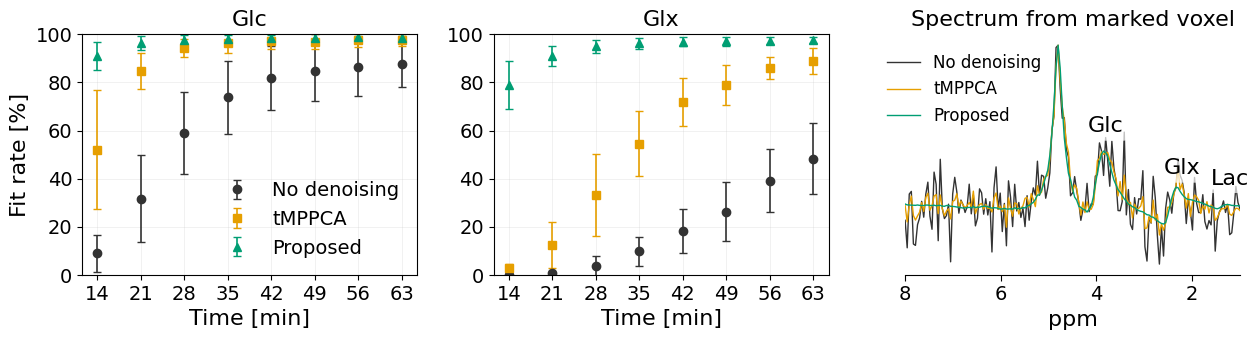

In [7]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

FONTSIZE = 16

# -------------------- STYLE / COLORS (paper-like, MRI) --------------------
DEFAULT_COLORS = {
    "noisy": "#333333",          # dark gray
    "tMPPCA_5D": "#E69F00",       # orange
    "deep_tMPPCA_5D": "#009E73",  # green
}
DEFAULT_MARKERS = {
    "noisy": "o",
    "tMPPCA_5D": "s",
    "deep_tMPPCA_5D": "^",
}

def apply_example_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        # "font.size": 12,
        # "axes.titlesize": 14,
        # "axes.labelsize": 13,
        # "xtick.labelsize": 12,
        # "ytick.labelsize": 12,
        # "legend.fontsize": 9,
        "axes.grid": False,
    })

def suffix_from_method(method: str) -> str:
    # "P08_deep_tMPPCA_5D" -> "deep_tMPPCA_5D"
    return method.split("_", 1)[1] if "_" in method else method


# -------------------- YOUR FIT-RATE PIPELINE (needed for stats_*) --------------------
def _suffix(quality_clip: bool, outlier_clip: bool) -> str:
    return "OutlierClip" if outlier_clip else ("QualityClip" if quality_clip else "Orig")

def load_sd_map(
    metabolite: str,
    method: str,
    *,
    data_dir: str = "MetabMaps",
    quality_clip: bool = False,
    outlier_clip: bool = False,
) -> np.ndarray:
    suffix = _suffix(quality_clip, outlier_clip)
    f_sd = os.path.join(data_dir, method, f"{metabolite}_sd_{method}_{suffix}.npy")
    if not os.path.isfile(f_sd):
        raise FileNotFoundError(f"SD map missing: {f_sd}")
    sd = np.load(f_sd)
    if sd.ndim != 4:
        raise ValueError(f"Unexpected SD shape {sd.shape}, expected (X,Y,Z,T).")
    return sd

def load_brain_mask(
    subject: str,
    *,
    tissue_dir: str = "../datasets",
) -> np.ndarray:
    mask_path = os.path.join(tissue_dir, subject, "mask.npy")
    if not os.path.isfile(mask_path):
        raise FileNotFoundError(f"Brain mask missing: {mask_path}")
    brain_mask = np.swapaxes(np.load(mask_path), 0, -1) > 0
    return brain_mask

def fit_rate_from_sd(
    sd_4d: np.ndarray,
    brain_mask: np.ndarray,
    *,
    crlb_thresh: float = 30.0,
) -> np.ndarray:
    if sd_4d.shape[:3] != brain_mask.shape:
        raise ValueError(f"Brain mask shape {brain_mask.shape} does not match SD map {sd_4d.shape[:3]}")
    T = sd_4d.shape[-1]
    rates = np.zeros(T, dtype=float)
    denom = brain_mask.sum()
    if denom == 0:
        return np.full(T, np.nan)
    for t in range(T):
        sd_t = sd_4d[..., t]
        ok = (sd_t <= crlb_thresh) & np.isfinite(sd_t) & brain_mask
        rates[t] = 100.0 * ok.sum() / denom
    return rates

def fit_rate_for_methods(
    metabolite: str,
    methods: list[str],
    subject: str,
    *,
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    quality_clip: bool = False,
    outlier_clip: bool = False,
    crlb_thresh: float = 30.0,
) -> dict[str, np.ndarray]:
    brain_mask = load_brain_mask(subject, tissue_dir=tissue_dir)
    out = {}
    for m in methods:
        sd = load_sd_map(
            metabolite, m,
            data_dir=data_dir,
            quality_clip=quality_clip,
            outlier_clip=outlier_clip,
        )
        out[m] = fit_rate_from_sd(sd, brain_mask, crlb_thresh=crlb_thresh)
    return out

def fit_rate_group_stats(
    metabolite: str,
    subjects: list[str],
    *,
    method_suffixes: list[str] = ["noisy", "deep_tMPPCA_5D", "tMPPCA_5D"],
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    crlb_thresh: float = 30.0,
    quality_clip: bool = False,
    outlier_clip: bool = False,
    strict: bool = False,
) -> dict[str, dict[str, np.ndarray]]:
    per_method = {suf: [] for suf in method_suffixes}
    for subj in subjects:
        methods = [f"{subj}_{suf}" for suf in method_suffixes]
        try:
            rates_dict = fit_rate_for_methods(
                metabolite, methods, subj,
                data_dir=data_dir,
                tissue_dir=tissue_dir,
                quality_clip=quality_clip,
                outlier_clip=outlier_clip,
                crlb_thresh=crlb_thresh,
            )
        except Exception as e:
            if strict:
                raise
            print(f"[WARN] Skipping {subj} ({metabolite}): {e}")
            continue

        for suf, m in zip(method_suffixes, methods):
            per_method[suf].append(rates_dict[m])

    stats = {}
    for suf, series_list in per_method.items():
        if len(series_list) == 0:
            stats[suf] = {"mean": np.array([np.nan]), "std": np.array([np.nan]), "n": np.array([0])}
            continue
        arr = np.stack(series_list, axis=0)  # (Nsub, T)
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr, axis=0, ddof=1) if arr.shape[0] > 1 else np.zeros_like(mean)
        n    = np.sum(np.isfinite(arr), axis=0)
        stats[suf] = {"mean": mean, "std": std, "n": n}
    return stats


# -------------------- SPECTRUM LOADER --------------------
def load_example_spectrum(
    base_dir: str,
    rep: int,
    xyz: tuple[int, int, int],
    filename: str = "SpecMap_LCMInput.nii.gz",
) -> np.ndarray:
    spec_path = os.path.join(base_dir, "maps", str(rep), "SpecMap", filename)
    if not os.path.isfile(spec_path):
        raise FileNotFoundError(f"Spektrum nicht gefunden: {spec_path}")
    data = nib.load(spec_path).get_fdata()
    if data.ndim != 4:
        raise ValueError(f"Erwarte 4D (X,Y,Z,S), gefunden: {data.shape}")
    x, y, z = xyz
    return np.asarray(data[x, y, z, :], dtype=np.float64).ravel()


# -------------------- FINAL PLOT (Group stats + example spectrum) --------------------
def plot_group_fitrate_two_metabs_plus_spectrum(
    *,
    stats_glc: dict[str, dict[str, np.ndarray]],
    stats_glx: dict[str, dict[str, np.ndarray]],
    methods: list[str],          # volle names: ["P08_noisy", ...] (nur für Spektrum + Style order)
    labels: list[str],
    minutes_per_rep: float = 7.0,
    ymax: float = 100.0,
    title: str = "",

    base_dir_root: str = "MetabMaps",
    spec_rep: int = 8,
    spec_xyz: tuple[int, int, int] = (12, 14, 11),
    spec_ppm: np.ndarray | None = None,
    spec_label: str = "Example spectra (marked in A)",
    peak_labels: dict[str, float] | None = None,

    savepath: str | None = None,
    colors_by_suffix: dict[str, str] | None = None,
    markers_by_suffix: dict[str, str] | None = None,
):
    assert len(methods) == len(labels)

    apply_example_style()
    if colors_by_suffix is None:
        colors_by_suffix = DEFAULT_COLORS
    if markers_by_suffix is None:
        markers_by_suffix = DEFAULT_MARKERS

    # suffix order comes from methods => consistent colors across ALL panels
    method_suffixes = [suffix_from_method(m) for m in methods]
    colors  = [colors_by_suffix.get(suf, "C0") for suf in method_suffixes]
    markers = [markers_by_suffix.get(suf, "o") for suf in method_suffixes]

    # infer T
    T = stats_glc[method_suffixes[0]]["mean"].shape[0]
    time_min = np.arange(2 * minutes_per_rep, minutes_per_rep * (T + 2), minutes_per_rep)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
    ax_glc, ax_glx, ax_spec = axes

    # Glc
    for suf, col, mk, lab in zip(method_suffixes, colors, markers, labels):
        y = stats_glc[suf]["mean"]
        e = stats_glc[suf]["std"]
        ax_glc.errorbar(time_min, y, yerr=e, fmt=mk, ms=6, elinewidth=1.2, capsize=3,
                        color=col, ecolor=col, label=lab)
    ax_glc.set_title("Glc")
    ax_glc.set_xlabel("Time [min]")
    ax_glc.set_ylabel("Fit rate [%]")
    ax_glc.grid(True, axis="both", alpha=0.2, linewidth=0.6)
    ax_glc.set_ylim(0, ymax)
    ax_glc.set_yticks(np.arange(0, ymax + 1, 20))
    ax_glc.set_xticks(time_min)
    ax_glc.legend(frameon=False, loc="lower right")

    # Glx
    for suf, col, mk in zip(method_suffixes, colors, markers):
        y = stats_glx[suf]["mean"]
        e = stats_glx[suf]["std"]
        ax_glx.errorbar(time_min, y, yerr=e, fmt=mk, ms=6, elinewidth=1.2, capsize=3,
                        color=col, ecolor=col)
    ax_glx.set_title("Glx")
    ax_glx.set_xlabel("Time [min]")
    ax_glx.grid(True, axis="both", alpha=0.2, linewidth=0.6)
    ax_glx.set_ylim(0, ymax)
    ax_glx.set_yticks(np.arange(0, ymax + 1, 20))
    ax_glx.set_xticks(time_min)

    # Spectra
    specs = []
    for method_full, col, lab in zip(methods, colors, labels):
        base_dir = os.path.join(base_dir_root, method_full)
        spec = load_example_spectrum(base_dir, spec_rep, spec_xyz)
        denom = np.nanmax(np.abs(spec))
        spec = spec / (denom if np.isfinite(denom) and denom != 0 else 1.0)
        specs.append(spec)
        x_axis = spec_ppm if spec_ppm is not None else np.arange(spec.size)
        ax_spec.plot(x_axis, spec, lw=1, color=col, label=lab)

    ax_spec.set_title(spec_label)
    ax_spec.set_xlabel("ppm" if spec_ppm is not None else "points")
    ax_spec.set_yticks([])

    # Clean spectrum frame: keep only x-axis
    for spine in ["top", "right", "left"]:
        ax_spec.spines[spine].set_visible(False)
    ax_spec.spines["bottom"].set_linewidth(0.8)

    ax_spec.tick_params(axis="x", direction="out", length=4, width=0.8)


    ax_spec.legend(
        frameon=False,
        loc="upper left",
        framealpha=0.8,
        fontsize=12,
        bbox_to_anchor=(-0.1, 0.98),
    )


    if spec_ppm is not None:
        ax_spec.set_xlim(np.max(spec_ppm), np.min(spec_ppm))

    if peak_labels is not None and spec_ppm is not None and len(specs) > 0:
        last_spec = specs[-1]
        for name, ppm_pos in peak_labels.items():
            idx = int(np.argmin(np.abs(spec_ppm - ppm_pos)))
            ax_spec.text(
                spec_ppm[idx], last_spec[idx] + 0.10, name,
                color="black", ha="center", va="bottom", fontsize=FONTSIZE,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.2")
            )

    plt.subplots_adjust(top=0.83)
    if title:
        fig.text(0.5, 0.88, title, ha="center", va="bottom", fontsize=13, weight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.86])
    else:
        plt.tight_layout()

    if savepath:
        if not savepath.lower().endswith(".pdf"):
            savepath += ".pdf"
        plt.savefig(savepath, dpi=300, bbox_inches="tight", transparent=True)
        print(f"💾 Saved as: {savepath}")

    plt.show()


# ===================== EXAMPLE: compute stats + plot =====================
# 1) group subjects
subjects = ["P03","P04","P05","P06","P07","P08"]  # <- ersetze durch deine Liste, z.B. ["P01","P02",...]
method_suffixes = ["noisy", "tMPPCA_5D", "deep_tMPPCA_5D"]  # <- Keys in stats_*

# 2) compute group stats
stats_glc = fit_rate_group_stats("Glc", subjects, method_suffixes=method_suffixes, crlb_thresh=30)
stats_glx = fit_rate_group_stats("Glx", subjects, method_suffixes=method_suffixes, crlb_thresh=30)

# 3) choose example subject for spectrum (muss in MetabMaps liegen)
methods = ["P08_noisy", "P08_tMPPCA_5D", "P08_deep_tMPPCA_5D"]
labels  = ["No denoising", "tMPPCA", "Proposed"]

import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 20,          # Basis (wirkt auf vieles)
    "axes.titlesize": 16,     # subplot titles ("Glc", "Glx", ...)
    "axes.labelsize": 16,     # Achsenlabels ("Time [min]", ...)
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

plot_group_fitrate_two_metabs_plus_spectrum(
    stats_glc=stats_glc,
    stats_glx=stats_glx,
    methods=methods,
    labels=labels,
    minutes_per_rep=7.0,
    ymax=100,
    title="",
    base_dir_root="MetabMaps",
    spec_rep=8,
    spec_xyz=(12, 14, 11),
    spec_ppm=np.linspace(8, 1, 163),
    spec_label="Spectrum from marked voxel",
    peak_labels={"Lac": 1.2, "Glx": 2.2, "Glc": 3.8},
    savepath="fitrate_group_plus_spectrum",
)



💾 Saved as: fitrate_group_two_panels.pdf


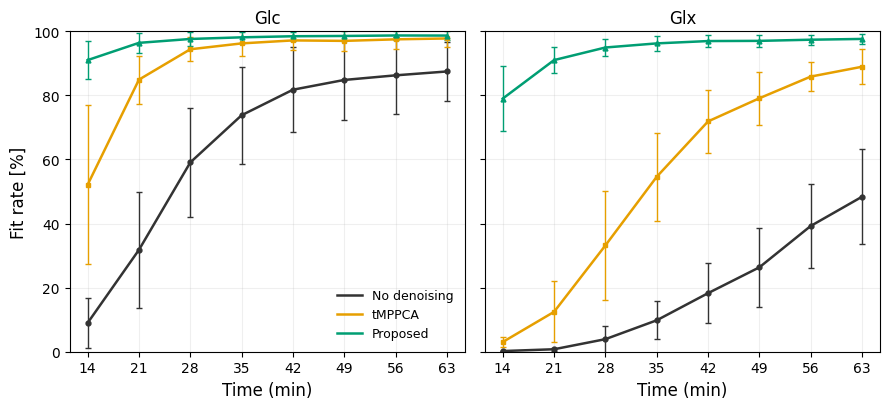

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

FONTSIZE = 16

# -------------------- STYLE / COLORS (paper-like, MRI) --------------------
DEFAULT_COLORS = {
    "noisy": "#333333",          # dark gray
    "tMPPCA_5D": "#E69F00",       # orange
    "deep_tMPPCA_5D": "#009E73",  # green
}
DEFAULT_MARKERS = {
    "noisy": "o",
    "tMPPCA_5D": "s",
    "deep_tMPPCA_5D": "^",
}

def apply_example_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.grid": False,
    })

def suffix_from_method(method: str) -> str:
    # "P08_deep_tMPPCA_5D" -> "deep_tMPPCA_5D"
    return method.split("_", 1)[1] if "_" in method else method


# -------------------- YOUR FIT-RATE PIPELINE (needed for stats_*) --------------------
def _suffix(quality_clip: bool, outlier_clip: bool) -> str:
    return "OutlierClip" if outlier_clip else ("QualityClip" if quality_clip else "Orig")

def load_sd_map(
    metabolite: str,
    method: str,
    *,
    data_dir: str = "MetabMaps",
    quality_clip: bool = False,
    outlier_clip: bool = False,
) -> np.ndarray:
    suffix = _suffix(quality_clip, outlier_clip)
    f_sd = os.path.join(data_dir, method, f"{metabolite}_sd_{method}_{suffix}.npy")
    if not os.path.isfile(f_sd):
        raise FileNotFoundError(f"SD map missing: {f_sd}")
    sd = np.load(f_sd)
    if sd.ndim != 4:
        raise ValueError(f"Unexpected SD shape {sd.shape}, expected (X,Y,Z,T).")
    return sd

def load_brain_mask(
    subject: str,
    *,
    tissue_dir: str = "../datasets",
) -> np.ndarray:
    mask_path = os.path.join(tissue_dir, subject, "mask.npy")
    if not os.path.isfile(mask_path):
        raise FileNotFoundError(f"Brain mask missing: {mask_path}")
    brain_mask = np.swapaxes(np.load(mask_path), 0, -1) > 0
    return brain_mask

def fit_rate_from_sd(
    sd_4d: np.ndarray,
    brain_mask: np.ndarray,
    *,
    crlb_thresh: float = 30.0,
) -> np.ndarray:
    if sd_4d.shape[:3] != brain_mask.shape:
        raise ValueError(f"Brain mask shape {brain_mask.shape} does not match SD map {sd_4d.shape[:3]}")
    T = sd_4d.shape[-1]
    rates = np.zeros(T, dtype=float)
    denom = brain_mask.sum()
    if denom == 0:
        return np.full(T, np.nan)
    for t in range(T):
        sd_t = sd_4d[..., t]
        ok = (sd_t <= crlb_thresh) & np.isfinite(sd_t) & brain_mask
        rates[t] = 100.0 * ok.sum() / denom
    return rates

def fit_rate_for_methods(
    metabolite: str,
    methods: list[str],
    subject: str,
    *,
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    quality_clip: bool = False,
    outlier_clip: bool = False,
    crlb_thresh: float = 30.0,
) -> dict[str, np.ndarray]:
    brain_mask = load_brain_mask(subject, tissue_dir=tissue_dir)
    out = {}
    for m in methods:
        sd = load_sd_map(
            metabolite, m,
            data_dir=data_dir,
            quality_clip=quality_clip,
            outlier_clip=outlier_clip,
        )
        out[m] = fit_rate_from_sd(sd, brain_mask, crlb_thresh=crlb_thresh)
    return out

def fit_rate_group_stats(
    metabolite: str,
    subjects: list[str],
    *,
    method_suffixes: list[str] = ["noisy", "deep_tMPPCA_5D", "tMPPCA_5D"],
    data_dir: str = "MetabMaps",
    tissue_dir: str = "../datasets",
    crlb_thresh: float = 30.0,
    quality_clip: bool = False,
    outlier_clip: bool = False,
    strict: bool = False,
) -> dict[str, dict[str, np.ndarray]]:
    per_method = {suf: [] for suf in method_suffixes}
    for subj in subjects:
        methods = [f"{subj}_{suf}" for suf in method_suffixes]
        try:
            rates_dict = fit_rate_for_methods(
                metabolite, methods, subj,
                data_dir=data_dir,
                tissue_dir=tissue_dir,
                quality_clip=quality_clip,
                outlier_clip=outlier_clip,
                crlb_thresh=crlb_thresh,
            )
        except Exception as e:
            if strict:
                raise
            print(f"[WARN] Skipping {subj} ({metabolite}): {e}")
            continue

        for suf, m in zip(method_suffixes, methods):
            per_method[suf].append(rates_dict[m])

    stats = {}
    for suf, series_list in per_method.items():
        if len(series_list) == 0:
            stats[suf] = {"mean": np.array([np.nan]), "std": np.array([np.nan]), "n": np.array([0])}
            continue
        arr = np.stack(series_list, axis=0)  # (Nsub, T)
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr, axis=0, ddof=1) if arr.shape[0] > 1 else np.zeros_like(mean)
        n    = np.sum(np.isfinite(arr), axis=0)
        stats[suf] = {"mean": mean, "std": std, "n": n}
    return stats


# -------------------- FINAL PLOT (Group stats, NO spectrum; paper font sizes) --------------------
def plot_group_fitrate_two_metabs(
    *,
    stats_glc: dict[str, dict[str, np.ndarray]],
    stats_glx: dict[str, dict[str, np.ndarray]],
    methods: list[str],          # e.g. ["P08_noisy", ...] (used for style/order)
    labels: list[str],
    minutes_per_rep: float = 7.0,
    ymax: float = 100.0,
    title: str = "",
    savepath: str | None = None,
    colors_by_suffix: dict[str, str] | None = None,
    markers_by_suffix: dict[str, str] | None = None,
):
    assert len(methods) == len(labels)

    apply_example_style()
    if colors_by_suffix is None:
        colors_by_suffix = DEFAULT_COLORS
    if markers_by_suffix is None:
        markers_by_suffix = DEFAULT_MARKERS

    # suffix order comes from methods => consistent colors across panels
    method_suffixes = [suffix_from_method(m) for m in methods]
    colors  = [colors_by_suffix.get(suf, "C0") for suf in method_suffixes]
    markers = [markers_by_suffix.get(suf, "o") for suf in method_suffixes]

    # infer T
    T = stats_glc[method_suffixes[0]]["mean"].shape[0]
    time_min = np.arange(2 * minutes_per_rep, minutes_per_rep * (T + 2), minutes_per_rep)

    # match your timecourse-metabolite-group style numbers
    lw, ms, cap = 1.8, 3.5, 2
    elw = 1.0

    fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.2), sharey=True)
    ax_glc, ax_glx = axes

    # --- Glc ---
    for suf, col, mk, lab in zip(method_suffixes, colors, markers, labels):
        y = stats_glc[suf]["mean"]
        e = stats_glc[suf]["std"]
        ax_glc.errorbar(
            time_min, y, yerr=e,
            color=col,
            linestyle="-",
            marker=mk,
            lw=lw, ms=ms,
            capsize=cap,
            elinewidth=elw,
            label=lab
        )

    ax_glc.set_title("Glc")
    ax_glc.set_xlabel("Time (min)")
    ax_glc.set_ylabel("Fit rate [%]")
    ax_glc.grid(True, alpha=0.2)
    ax_glc.set_ylim(0, ymax)
    ax_glc.set_yticks(np.arange(0, ymax + 1, 20))
    ax_glc.set_xticks(time_min)

    # --- Glx ---
    for suf, col, mk, lab in zip(method_suffixes, colors, markers, labels):
        y = stats_glx[suf]["mean"]
        e = stats_glx[suf]["std"]
        ax_glx.errorbar(
            time_min, y, yerr=e,
            color=col,
            linestyle="-",
            marker=mk,
            lw=lw, ms=ms,
            capsize=cap,
            elinewidth=elw,
            label=lab
        )

    ax_glx.set_title("Glx")
    ax_glx.set_xlabel("Time (min)")
    ax_glx.grid(True, alpha=0.2)
    ax_glx.set_ylim(0, ymax)
    ax_glx.set_yticks(np.arange(0, ymax + 1, 20))
    ax_glx.set_xticks(time_min)

    # Legend (match timecourse style: frameoff + small)
    handles = [
        Line2D([0], [0], color=colors_by_suffix.get(suf, "k"), lw=lw, label=lab)
        for suf, lab in zip(method_suffixes, labels)
    ]
    ax_glc.legend(handles=handles, frameon=False, loc="lower right", fontsize=9)
    
    if title:
        fig.suptitle(title)

    plt.tight_layout()

    if savepath:
        if not savepath.lower().endswith(".pdf"):
            savepath += ".pdf"
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"💾 Saved as: {savepath}")

    plt.show()


# ===================== EXAMPLE: compute stats + plot =====================
subjects = ["P03", "P04", "P05", "P06", "P07", "P08"]
method_suffixes = ["noisy", "tMPPCA_5D", "deep_tMPPCA_5D"]

stats_glc = fit_rate_group_stats("Glc", subjects, method_suffixes=method_suffixes, crlb_thresh=30)
stats_glx = fit_rate_group_stats("Glx", subjects, method_suffixes=method_suffixes, crlb_thresh=30)

methods = ["P08_noisy", "P08_tMPPCA_5D", "P08_deep_tMPPCA_5D"]
labels  = ["No denoising", "tMPPCA", "Proposed"]

# --- Paper-like font sizes (replace your old big rcParams) ---
mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

plot_group_fitrate_two_metabs(
    stats_glc=stats_glc,
    stats_glx=stats_glx,
    methods=methods,
    labels=labels,
    minutes_per_rep=7.0,
    ymax=100,
    title="",
    savepath="fitrate_group_two_panels",
)

    
